# 12. Model evaluation

<div class="callout callout-note">
Language: <strong>Python</strong> (Jupyter) - <a href="r.qmd">R version</a>
</div>

[Example 21](../21-flood-frequency/python.ipynb) fits LogNormal, GEV, and Weibull to a 48-year
peak-flow record and ranks them by log-likelihood and AIC, setting the upstream script's
Kolmogorov-Smirnov ranking aside. This example picks it back up, revisiting the same record with
the whole goodness-of-fit toolbox -- `goodness_of_fit()`, `gof_test()`, `gof_rmse()`,
`aic()`/`aic_weights()` -- and confirms the KS statistic agrees with the AIC ranking. It has no
upstream counterpart: the USACE-RMC Numerics-Python-Examples repository has no dedicated
model-comparison notebook.

## What you'll learn

- Fit several candidate distributions to one flood series and score each with a goodness-of-fit
  test statistic (`gof_test`), not just log-likelihood.
- Rank candidates with `aic()`/`aic_weights()`, and read an Akaike weight as "the probability
  this model is the best of the set, given the set."
- Score a fitted quantile curve against the data with `goodness_of_fit()`'s general continuous
  metrics (NSE, KGE, R-squared, ...), the same metrics used to evaluate any modeled-versus-observed
  series, not just a distribution fit.
- `classification_metrics()` for a binary comparison, illustrated (a little artificially) on an
  above/below-median split.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import corehydropy as ch

## The data

The same 48 years of annual peak flows (cfs) as example 21.

In [2]:
peak_flows = np.array([
    6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000,
    17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600,
    14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600,
    14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600,
    13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460,
], dtype=float)
n = len(peak_flows)
print(f"n = {n} peak flows, {peak_flows.min():,.0f} to {peak_flows.max():,.0f} cfs")

n = 48 peak flows, 2,700 to 22,600 cfs


## Fit four candidates

LogNormal and Weibull by maximum likelihood, GEV by L-moments (as in example 21), plus Gumbel by
maximum likelihood as a fourth candidate.

In [3]:
ln = ch.Distribution.fit("LogNormal", peak_flows, method="mle")
gev = ch.Distribution.fit("GeneralizedExtremeValue", peak_flows, method="lmom")
wb = ch.Distribution.fit("Weibull", peak_flows, method="mle")
gum = ch.Distribution.fit("Gumbel", peak_flows, method="mle")

models = {"LogNormal": ln, "GEV": gev, "Weibull": wb, "Gumbel": gum}

## Rank with goodness-of-fit test statistics

`gof_test()` mirrors the C# `GoodnessOfFit` class's Kolmogorov-Smirnov D and Anderson-Darling
A-squared statistics for a fitted distribution against its data -- smaller is a better fit for
both. `gof_rmse()` compares the fitted quantiles at Weibull plotting positions to the sorted
data. `aic()` needs only the parameter count and the log-likelihood `Distribution.log_likelihood()`
already provides; `aic_weights()` turns a list of AIC values into weights that sum to one, each
reading as "the (relative) probability this is the best model of the set."

`aic()`/`gof_test()`/`gof_rmse()` take one model at a time, so a dict comprehension builds the
table one candidate at a time -- there is no vectorized "rank these four" verb, deliberately: the
toolbox mirrors the C# statics one call at a time, and ranking is a few lines of Python on top.

In [4]:
k = {name: len(d.params) for name, d in models.items()}
log_lik = {name: d.log_likelihood(peak_flows) for name, d in models.items()}
aics = {name: ch.aic(k[name], log_lik[name]) for name in models}
ks = {name: ch.gof_test(peak_flows, d, test="ks") for name, d in models.items()}
ad = {name: ch.gof_test(peak_flows, d, test="ad") for name, d in models.items()}
rmse_v = {name: ch.gof_rmse(peak_flows, d) for name, d in models.items()}
weights = dict(zip(models, ch.aic_weights([aics[name] for name in models])))

ranking = pd.DataFrame({
    "Model": list(models),
    "k": [k[m] for m in models],
    "LogLik": [log_lik[m] for m in models],
    "AIC": [aics[m] for m in models],
    "KS": [ks[m] for m in models],
    "AD": [ad[m] for m in models],
    "RMSE": [rmse_v[m] for m in models],
    "AkaikeWeight": [weights[m] for m in models],
}).sort_values("AIC").reset_index(drop=True)
print(ranking.to_string(index=False))

    Model  k      LogLik        AIC       KS       AD       RMSE  AkaikeWeight
  Weibull  2 -473.045841 950.091683 0.066387 0.251832 547.452739      0.707012
      GEV  3 -473.222666 952.445331 0.069694 0.250618 481.526769      0.217941
   Gumbel  2 -475.457294 954.914589 0.113110 0.586797 719.701276      0.063408
LogNormal  2 -477.152483 958.304966 0.134511 0.841572 874.869480      0.011640


Weibull wins on AIC, KS, and RMSE, carrying 71% of the Akaike weight -- confirming, with an
actual goodness-of-fit test statistic this time, exactly what example 21 found by log-likelihood
alone: "Weibull edges out GEV, and LogNormal trails." Anderson-Darling is the one holdout: it
weights tail deviations more heavily than KS, and by that measure GEV's A-squared (0.2506) edges
Weibull's (0.2518) -- the two are close enough, and the metrics disagree closely enough, that this
is a real illustration of why a ranking should look at more than one statistic rather than an
example built to make every metric agree.

## Score the winning quantile curve

`goodness_of_fit()` is the general-purpose continuous-metrics verb: any modeled-versus-observed
pair, not just a fitted distribution. Comparing the Weibull quantile curve at the data's own
plotting positions to the sorted observations treats the frequency curve itself as "the model"
and scores it with NSE, KGE, R-squared and friends -- the standard hydrologic model-evaluation
metrics, repurposed here for a frequency curve.

In [5]:
pp = np.asarray(ch.plotting_positions(n))
sorted_flows = np.sort(peak_flows)
modeled = np.asarray(wb.quantile(pp))

fit_scores = ch.goodness_of_fit(sorted_flows, modeled)
print({key: round(val, 4) for key, val in fit_scores.items()})

{'rmse': 553.485, 'mse': 306345.6538, 'mae': 446.4293, 'mape': 4.506, 'smape': 4.3044, 'nse': 0.9859, 'log_nse': 0.9751, 'kge': 0.9355, 'kge_mod': 0.9365, 'pbias': -0.1088, 'rsr': 0.1188, 'pearson': 0.9947, 'r_squared': 0.9894, 'd': 0.9962, 'd_mod': 0.9392, 'd_ref': 0.9407, 've': 0.9648}


NSE above 0.98 and KGE above 0.93 both say the same thing the AIC ranking already said: the
Weibull quantile curve tracks the sorted record closely apart from the usual upper-tail spread.

## A binary comparison: `classification_metrics()`

`classification_metrics()` compares two already-binary label vectors -- it has no threshold
argument, in Python or in C#, so the labels are built by hand first. This is a contrived use for
a frequency curve (nothing about flood-frequency analysis is naturally binary), but it is the
only public verb that exposes the C# `GoodnessOfFit` classification statics, so it is worth
seeing once: label each year "above the median flow" or not, in both the observed record and the
fitted quantile curve at the same rank, and score the agreement.

In [6]:
med = np.median(peak_flows)
obs_label = (sorted_flows > med).astype(float)
mod_label = (modeled > med).astype(float)
cls = ch.classification_metrics(obs_label, mod_label)
print({key: round(val, 4) for key, val in cls.items()})

{'accuracy': 95.8333, 'precision': 1.0, 'recall': 0.9167, 'f1': 0.9565, 'specificity': 1.0, 'balanced_accuracy': 0.9583}


## Plot: fitted curves against plotting positions

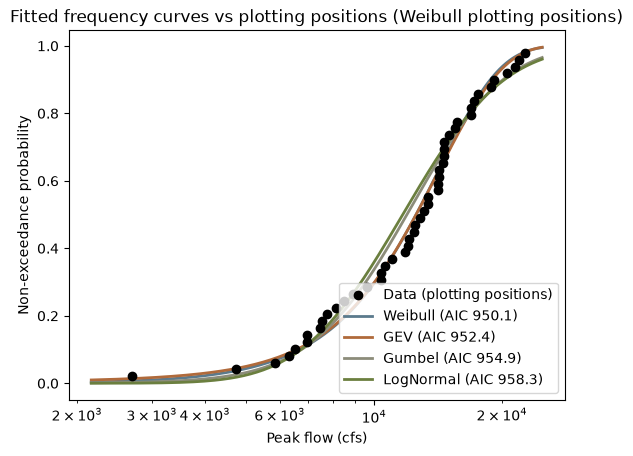

In [7]:
colors = {"LogNormal": "#6b7f3f", "GEV": "#b06a3b", "Weibull": "#5b7a8c", "Gumbel": "#8c8c7a"}
x_grid = np.linspace(peak_flows.min() * 0.8, peak_flows.max() * 1.1, 500)

plt.scatter(sorted_flows, pp, color="black", zorder=3, label="Data (plotting positions)")
for _, row in ranking.iterrows():
    name = row["Model"]
    plt.plot(x_grid, models[name].cdf(x_grid), color=colors[name], linewidth=2,
              label=f"{name} (AIC {row['AIC']:.1f})")
plt.xscale("log")
plt.xlabel("Peak flow (cfs)")
plt.ylabel("Non-exceedance probability")
plt.title("Fitted frequency curves vs plotting positions (Weibull plotting positions)")
plt.legend(loc="lower right")
plt.show()

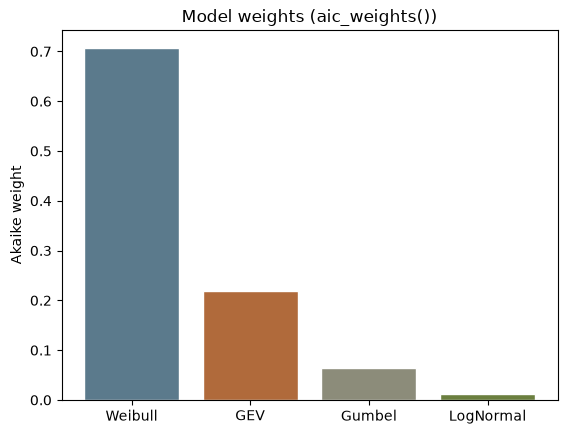

In [8]:
order = ranking["Model"].tolist()
plt.bar(order, [weights[m] for m in order], color=[colors[m] for m in order], edgecolor="white")
plt.ylabel("Akaike weight")
plt.title("Model weights (aic_weights())")
plt.show()

## Key takeaways

1. `gof_test()` and `gof_rmse()` give a fitted distribution the same KS/AD/RMSE ranking the C#
   `GoodnessOfFit` class always offered, which is what example 21 sets aside.
2. `aic_weights()` turns a table of AIC values into normalized weights -- useful directly, and
   the same weights `fit_distributions()`'s composite-model machinery consumes internally.
3. `goodness_of_fit()` is not distribution-specific: it scores any two equal-length numeric
   series, so it works as well on a frequency curve as on a rainfall-runoff hydrograph.
4. `classification_metrics()` fills out the C# `GoodnessOfFit` surface for binary comparisons,
   even though flood-frequency analysis rarely needs one.

## Reproduction check

No upstream literals exist for this example (it has no upstream counterpart), so every value
below is an internal-consistency and cross-language check: the ranking is self-consistent (AIC
order matches the KS order here, and matches the AD order everywhere except the top two, as
discussed above), and the literals are the exact values the R twin asserts too -- both languages
run the same seeded/deterministic core, so the match is bit-exact.

In [9]:
order_aic = ranking.sort_values("AIC")["Model"].tolist()
order_ks = sorted(models, key=lambda m: ks[m])
order_ad = sorted(models, key=lambda m: ad[m])

assert order_aic == order_ks
assert order_aic[2:] == order_ad[2:]
assert set(order_aic[:2]) == set(order_ad[:2])
assert order_aic[0] == "Weibull"
assert abs(sum(weights.values()) - 1) < 1e-12

# Cross-language identity: the R twin asserts these same literals.
assert aics["LogNormal"] == 958.3049663960251
assert aics["GEV"] == 952.4453310373827
assert aics["Weibull"] == 950.091682565358
assert aics["Gumbel"] == 954.9145885092263
assert ks["Weibull"] == 0.06638744856290868
assert ad["Weibull"] == 0.2518324119771691
assert rmse_v["Weibull"] == 547.4527389046023
assert weights["Weibull"] == 0.7070115798971689
assert fit_scores["nse"] == 0.985895395879688
assert fit_scores["kge"] == 0.9354991216938189
assert fit_scores["r_squared"] == 0.9893788517543065
assert fit_scores["pearson"] == 0.994675249392638
assert cls["accuracy"] == 95.83333333333333
print("All reproduction checks passed.")

All reproduction checks passed.
